# Guía de Laboratorio — Semana 1: Estadística Descriptiva paso a paso
### Caso: Control de Calidad (Cajas de Helado de 500 g)

Este cuaderno acompaña la **presentación interactiva** (`index.html`). Cada paso corresponde a una diapositiva:

| Paso del cuaderno | Diapositiva de la presentación |
| :--- | :--- |
| Paso 0 – Datos y muestreo | 03 · Muestreo en Python |
| Paso 1 – Tabla de frecuencias | 03 · Tabla de Frecuencias (Sturges) |
| Paso 2 – Tendencia central | 02 · Estimación de la Localización |
| Paso 3 – Dispersión | 02 · Estimación de la Variabilidad |
| Paso 4 – Forma (asimetría y curtosis) | 02 · Exploración de la Distribución |
| Paso 5 – Histograma | 03 · Histograma y Análisis |

**Cómo usarlo:** primero lee el cálculo a mano (celdas de texto) y luego ejecuta la celda de Python que lo comprueba. Si los dos resultados coinciden, entendiste el procedimiento.

> Los datos para practicar están en `Taller_Est_desc.ipynb`.

---
## PASO 0: Los datos crudos ($n = 30$)

Pesamos 30 cajas que salieron de la línea de producción. Ordenadas de menor a mayor:

**494, 495, 496, 497, 497, 497, 498, 498, 498, 499, 499, 499, 499, 500, 500, 500, 500, 501, 501, 501, 502, 502, 502, 503, 503, 503, 504, 504, 505, 506**

> **Comprobación:** la suma de los 30 datos es $\sum x_i = 15\,003$ g.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

datos = np.array([
    494, 495, 496, 497, 497, 497, 498, 498, 498, 499,
    499, 499, 499, 500, 500, 500, 500, 501, 501, 501,
    502, 502, 502, 503, 503, 503, 504, 504, 505, 506
])
n = len(datos)
print(f"n = {n}  |  suma = {datos.sum()}  |  mínimo = {datos.min()}  |  máximo = {datos.max()}")

n = 30  |  suma = 15003  |  mínimo = 494  |  máximo = 506


### Paso 0.1: ¿Muestra o población?

Las 30 cajas **no son toda la producción**, son una **muestra**. Por eso:
- Usamos $n - 1$ en la varianza muestral ($s^2$).
- La muestra debe ser **aleatoria**: si solo pesamos las cajas del turno de la mañana, podemos sacar conclusiones sesgadas.

La siguiente celda simula una producción de 1 000 cajas en dos turnos y compara dos formas de muestrear.

In [2]:
rng = np.random.default_rng(42)
produccion = pd.DataFrame({
    "turno": rng.choice(["Mañana", "Noche"], size=1000, p=[0.6, 0.4]),
    "peso": rng.normal(loc=500, scale=3, size=1000).round(),
})

# 1. Muestreo aleatorio simple: cada caja tiene la misma probabilidad de salir
muestra_simple = produccion.sample(n=30, random_state=42)

# 2. Muestreo estratificado: respeta la proporción de cada turno (60% / 40%)
muestra_estrat = produccion.groupby("turno", group_keys=False).sample(frac=0.03, random_state=42)

print("Proporción por turno en la población:\n", produccion["turno"].value_counts(normalize=True).round(2))
print("\nMuestra simple:\n", muestra_simple["turno"].value_counts(normalize=True).round(2))
print("\nMuestra estratificada:\n", muestra_estrat["turno"].value_counts(normalize=True).round(2))

Proporción por turno en la población:
 turno
Mañana    0.6
Noche     0.4
Name: proportion, dtype: float64

Muestra simple:
 turno
Mañana    0.6
Noche     0.4
Name: proportion, dtype: float64

Muestra estratificada:
 turno
Mañana    0.6
Noche     0.4
Name: proportion, dtype: float64


---
## PASO 1: Organización (Tabla de Frecuencias)

### Paso 1.1: Rango ($R$)
$$R = \text{Dato}_{max} - \text{Dato}_{min} = 506 - 494 = 12$$

### Paso 1.2: Número de intervalos ($k$) con la Regla de Sturges

¿Por qué no elegir el número de filas a ojo? Con **muy pocos intervalos** todo queda en un solo bloque y no se ve la forma. Con **demasiados** quedan filas vacías y el histograma parece un peine. Sturges da un punto intermedio que crece lentamente con $n$:

$$k = 1 + 3.322 \cdot \log_{10}(n)$$

1. $\log_{10}(30) \approx 1.477$
2. $3.322 \cdot 1.477 \approx 4.90$
3. $1 + 4.90 = 5.90$
4. **Redondeo** al entero más cercano: **$k = 6$**

### Paso 1.3: Amplitud ($A$)
$$A = \frac{R}{k} = \frac{12}{6} = 2$$

> **Resultado:** la tabla tendrá **6 filas** y cada una avanza de **2 en 2** gramos.

| Intervalo $[L_i, L_s)$ | Marca ($x_i$) | Frecuencia ($f_i$) | Relativa ($h_i = f_i/n$) | Acumulada ($F_i$) |
| :--- | :---: | :---: | :---: | :---: |
| **[494 – 496)** | 495 | 2 | $2/30 \approx 0.067$ | 2 |
| **[496 – 498)** | 497 | 4 | $4/30 \approx 0.133$ | 6 |
| **[498 – 500)** | 499 | 7 | $7/30 \approx 0.233$ | 13 |
| **[500 – 502)** | 501 | 7 | $7/30 \approx 0.233$ | 20 |
| **[502 – 504)** | 503 | 6 | $6/30 = 0.200$ | 26 |
| **[504 – 506]** | 505 | 4 | $4/30 \approx 0.133$ | 30 |
| **TOTAL** | | **$n=30$** | **$1.000$** | |

> **Notación:** `[` incluye el número y `)` llega "hasta casi" ese número. Por eso el **496** se cuenta en la segunda fila. El **último** intervalo se cierra con `]` para que el 506 no quede por fuera.
>
> **Ojo con el redondeo:** con dos decimales, las $h_i$ suman $0.07+0.13+0.23+0.23+0.20+0.13 = 0.99$. Es solo efecto del redondeo; con tres decimales la suma da 1.

In [3]:
# Regla de Sturges (redondeo al entero más cercano)
k = round(1 + 3.322 * np.log10(n))
R = datos.max() - datos.min()
A = R / k
print(f"R = {R}  |  k = {k}  |  A = {A}")

# Límites de clase: 494, 496, ..., 506
bordes = np.arange(datos.min(), datos.max() + A, A)

# np.histogram usa intervalos [a, b) y CIERRA el último: [504, 506]
fi, _ = np.histogram(datos, bins=bordes)

tabla = pd.DataFrame({
    "Intervalo": [f"[{int(a)} – {int(b)}{']' if i == k - 1 else ')'}" for i, (a, b) in enumerate(zip(bordes[:-1], bordes[1:]))],
    "x_i": (bordes[:-1] + bordes[1:]) / 2,
    "f_i": fi,
})
tabla["h_i"] = (tabla["f_i"] / n).round(3)
tabla["F_i"] = tabla["f_i"].cumsum()
tabla["x_i·f_i"] = tabla["x_i"] * tabla["f_i"]
tabla

R = 12  |  k = 6  |  A = 2.0


,Intervalo,x_i,f_i,h_i,F_i,x_i·f_i
0,[494 – 496),495.0,2,0.067,2,990.0
1,[496 – 498),497.0,4,0.133,6,1988.0
2,[498 – 500),499.0,7,0.233,13,3493.0
3,[500 – 502),501.0,7,0.233,20,3507.0
4,[502 – 504),503.0,6,0.200,26,3018.0
5,[504 – 506],505.0,4,0.133,30,2020.0


---
## PASO 2: Medidas de Tendencia Central (¿Dónde está el centro?)

### Con los datos individuales (valor exacto)

1. **Media ($\bar{x}$):** el punto de equilibrio de los datos.
   $$\bar{x} = \frac{\sum x_i}{n} = \frac{15\,003}{30} = 500.1 \text{ g}$$
   *Interpretación: en promedio, las cajas pesan 0.1 g más que el objetivo.*

2. **Mediana ($\tilde{x}$):** con 30 datos, es el promedio de las posiciones 15 y 16.
   $$\tilde{x} = \frac{500 + 500}{2} = 500 \text{ g}$$

3. **Moda ($Mo$):** **499** y **500** aparecen 4 veces cada uno → distribución **bimodal**.

### Con la tabla de frecuencias (valor aproximado)

Cuando solo tenemos la tabla, suponemos que todas las cajas de un intervalo pesan lo que su marca de clase $x_i$:

$$\bar{x}_{agrupada} = \frac{\sum x_i \cdot f_i}{n} = \frac{990 + 1988 + 3493 + 3507 + 3018 + 2020}{30} = \frac{15\,016}{30} \approx 500.53 \text{ g}$$

> **¿Por qué no da 500.1?** Al agrupar perdemos el valor exacto de cada caja. Esa diferencia se llama **error de agrupamiento**: se gana rapidez y se sacrifica un poco de precisión.
>
> **Regla importante:** si trabajas con la tabla, usa **la media agrupada** en los cálculos siguientes (varianza, curtosis). No mezcles la media de los datos sueltos con las marcas de clase.

In [4]:
media = datos.mean()
mediana = np.median(datos)
valores, conteos = np.unique(datos, return_counts=True)
modas = valores[conteos == conteos.max()]

media_agrupada = (tabla["x_i"] * tabla["f_i"]).sum() / n

print(f"Media (datos individuales): {media:.2f} g")
print(f"Mediana:                    {mediana:.2f} g")
print(f"Moda(s):                    {modas.tolist()}  (cada una aparece {conteos.max()} veces)")
print(f"Media agrupada (tabla):     {media_agrupada:.2f} g")

Media (datos individuales): 500.10 g
Mediana:                    500.00 g
Moda(s):                    [499, 500]  (cada una aparece 4 veces)
Media agrupada (tabla):     500.53 g


---
## PASO 3: Medidas de Dispersión (¿Qué tan variable es?)

### Con los datos individuales
$$s^2 = \frac{\sum (x_i - \bar{x})^2}{n - 1} = \frac{254.7}{29} \approx 8.78 \qquad s = \sqrt{8.78} \approx 2.96 \text{ g}$$

*Interpretación: una caja típica se aleja unos $\pm 2.96$ g del peso promedio.*

### Con la tabla de frecuencias (usando $\bar{x}_{agrupada} = 500.53$)

| Marca ($x_i$) | $f_i$ | $(x_i - \bar{x})$ | $(x_i - \bar{x})^2$ | $f_i \cdot (x_i - \bar{x})^2$ |
| :---: | :---: | :---: | :---: | :---: |
| 495 | 2 | $-5.53$ | $30.62$ | $61.24$ |
| 497 | 4 | $-3.53$ | $12.48$ | $49.94$ |
| 499 | 7 | $-1.53$ | $2.35$ | $16.46$ |
| 501 | 7 | $0.47$ | $0.22$ | $1.52$ |
| 503 | 6 | $2.47$ | $6.08$ | $36.51$ |
| 505 | 4 | $4.47$ | $19.95$ | $79.80$ |
| **TOTAL** | **30** | | | **$\sum = 245.47$** |

$$s^2 = \frac{\sum f_i (x_i - \bar{x})^2}{n - 1} = \frac{245.47}{29} \approx 8.46 \qquad s = \sqrt{8.46} \approx 2.91 \text{ g}$$

> Otra vez, el valor agrupado (2.91) es cercano al exacto (2.96) pero no igual: es el error de agrupamiento.

### Rango intercuartílico (IQR)
$Q_1 = 498$, $Q_3 = 502$ → $IQR = 502 - 498 = 4$ g. El 50 % central de las cajas pesa entre 498 y 502 g. Los límites para detectar atípicos son $Q_1 - 1.5 \cdot IQR = 492$ y $Q_3 + 1.5 \cdot IQR = 508$: **no hay atípicos**.

In [5]:
var_ind = datos.var(ddof=1)            # ddof=1  ->  divide entre n - 1
s_ind = datos.std(ddof=1)

dev_agr = tabla["x_i"] - media_agrupada
var_agr = (tabla["f_i"] * dev_agr**2).sum() / (n - 1)

q1, q3 = np.percentile(datos, [25, 75])
iqr = q3 - q1

print(f"Individual: s² = {var_ind:.2f}   s = {s_ind:.2f} g")
print(f"Agrupada:   s² = {var_agr:.2f}   s = {np.sqrt(var_agr):.2f} g")
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}  ->  límites de atípicos: [{q1 - 1.5*iqr}, {q3 + 1.5*iqr}]")

Individual: s² = 8.78   s = 2.96 g
Agrupada:   s² = 8.46   s = 2.91 g
Q1 = 498.0, Q3 = 502.0, IQR = 4.0  ->  límites de atípicos: [492.0, 508.0]


---
## PASO 4: Forma de la distribución

### 4.1 Asimetría
La media (500.1) y la mediana (500) son casi iguales, y el coeficiente de asimetría da $\approx -0.02$. La distribución es **prácticamente simétrica**.

### 4.2 Curtosis: ¿punta de aguja o mesa plana?

| Tipo | Coeficiente | Forma |
| :--- | :---: | :--- |
| **Leptocúrtica** | $K > 0$ | Puntiaguda: datos muy amontonados en el centro y colas pesadas |
| **Mesocúrtica** | $K \approx 0$ | Como la distribución Normal |
| **Platicúrtica** | $K < 0$ | Achatada: datos repartidos de forma más uniforme |

#### Hay DOS fórmulas de curtosis, y dan números distintos

**A. Curtosis por momentos (poblacional, $g_2$).** Es la definición teórica. Ojo: aquí la varianza se divide entre $n$, no entre $n-1$:
$$K_A = \frac{m_4}{m_2^{\,2}} - 3, \qquad m_2 = \frac{\sum (x_i - \bar{x})^2}{n}, \quad m_4 = \frac{\sum (x_i - \bar{x})^4}{n}$$

- **Datos individuales:** $m_2 = 254.7/30 = 8.49$, $m_4 = 5\,189.09/30 = 172.97$
  $$K_A = \frac{172.97}{8.49^2} - 3 = \frac{172.97}{72.08} - 3 \approx 2.40 - 3 = \mathbf{-0.60}$$
- **Datos agrupados** (con $\bar{x} = 500.53$): $\sum f_i (x_i - \bar{x})^4 = 4\,351.68$ y $m_2 = 245.47/30 = 8.18$
  $$K_A = \frac{4\,351.68 / 30}{8.18^2} - 3 = \frac{145.06}{66.95} - 3 \approx 2.17 - 3 = \mathbf{-0.83}$$

**B. Curtosis muestral corregida (Excel `=CURTOSIS`, pandas `.kurt()`).** Ajusta el sesgo que aparece con muestras pequeñas:
$$K_B = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)} \approx \mathbf{-0.48}$$

#### ¿Por qué difieren?
1. **A vs B:** B corrige que una muestra pequeña ($n = 30$) tiende a subestimar o sobreestimar las colas. Cuando $n$ es muy grande, A y B casi coinciden.
2. **Individual vs agrupada:** al reemplazar cada dato por su marca de clase, se pierde información y los valores se "empujan" hacia los bordes de los intervalos.
3. **Error frecuente:** mezclar fórmulas, por ejemplo usar $s$ (con $n-1$) dentro de la fórmula A, o usar la media de los datos sueltos con las marcas de clase. Eso produce un número que no corresponde a ninguna de las dos versiones.

#### Interpretación
Las tres versiones dan un valor **negativo y pequeño** ($-0.48$ a $-0.83$): la distribución es **ligeramente platicúrtica**. La máquina no produce un pico marcado en 500 g; los pesos se reparten de forma bastante pareja entre 497 y 504 g.

> **Para verificar en Excel:** `=CURTOSIS(rango)` debe darte **−0.48** (versión B).

In [6]:
# Asimetría
print(f"Asimetría (g1): {stats.skew(datos):.3f}")

# A. Curtosis por momentos (poblacional)
K_A_ind = stats.kurtosis(datos, fisher=True, bias=True)
m2_agr = (tabla["f_i"] * dev_agr**2).sum() / n
m4_agr = (tabla["f_i"] * dev_agr**4).sum() / n
K_A_agr = m4_agr / m2_agr**2 - 3

# B. Curtosis muestral corregida (la misma de Excel =CURTOSIS)
K_B = pd.Series(datos).kurt()

print(f"Curtosis A (momentos) – individual: {K_A_ind:.2f}")
print(f"Curtosis A (momentos) – agrupada:   {K_A_agr:.2f}")
print(f"Curtosis B (Excel / pandas):        {K_B:.2f}")

Asimetría (g1): -0.018
Curtosis A (momentos) – individual: -0.60
Curtosis A (momentos) – agrupada:   -0.83
Curtosis B (Excel / pandas):        -0.48


---
## PASO 5: Histograma (visualización)

Primero, a mano (una barra = una caja):

```text
Intervalo      | Frecuencia
494 – 496      | ██ (2)
496 – 498      | ████ (4)
498 – 500      | ███████ (7)
500 – 502      | ███████ (7)
502 – 504      | ██████ (6)
504 – 506      | ████ (4)
```

Ahora con Python. Las líneas verticales marcan la media y la mediana: como casi coinciden, confirman que la distribución es simétrica.

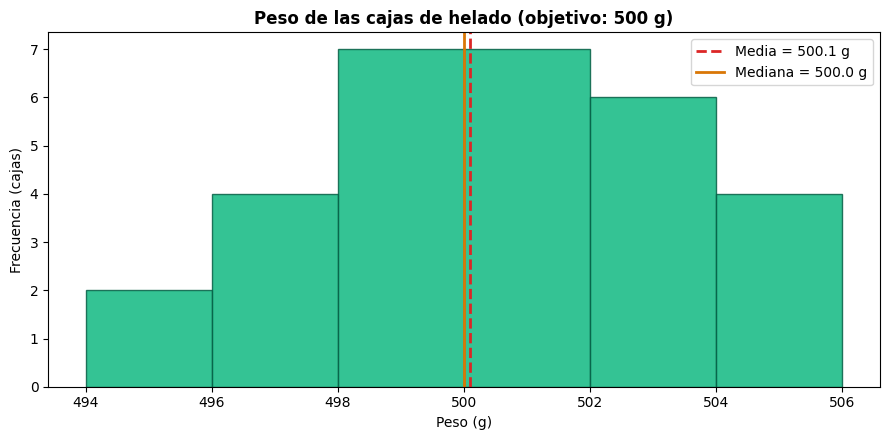

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(datos, bins=bordes, color="#10b981", edgecolor="#065f46", alpha=0.85)
ax.axvline(media, color="#dc2626", linestyle="--", linewidth=2, label=f"Media = {media:.1f} g")
ax.axvline(mediana, color="#d97706", linestyle="-", linewidth=2, label=f"Mediana = {mediana:.1f} g")
ax.set_xticks(bordes)
ax.set_title("Peso de las cajas de helado (objetivo: 500 g)", fontweight="bold")
ax.set_xlabel("Peso (g)")
ax.set_ylabel("Frecuencia (cajas)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Resumen del caso

| Medida | Datos individuales | Tabla agrupada |
| :--- | :---: | :---: |
| Media | 500.10 g | 500.53 g |
| Mediana | 500.00 g | — |
| Moda | 499 y 500 (bimodal) | intervalos [498–500) y [500–502) |
| Varianza ($s^2$) | 8.78 | 8.46 |
| Desviación estándar ($s$) | 2.96 g | 2.91 g |
| Curtosis A (momentos) | −0.60 | −0.83 |
| Curtosis B (Excel) | −0.48 | — |

**Conclusión:** el proceso está centrado en el objetivo (≈ 500 g), es simétrico, no tiene atípicos y su variación típica es de unos ±3 g, con una forma ligeramente achatada.

### 📝 Ejercicio
Abre `Taller_Est_desc.ipynb`, toma el conjunto **1. Peso Café (g)**, cambia el arreglo `datos` de la primera celda de código y vuelve a ejecutar todo el cuaderno. Luego interpreta cada resultado con tus palabras.